In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
data=pd.read_csv("ai_workforce_displacement_global_2020_2026.csv")
data['quarter_label'] = pd.Categorical(data['quarter_label'], ordered=True)

In [46]:
data=data.drop('data_source_notes',axis=1)

In [47]:
data

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0406,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0517,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0176,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0924,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0667,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20795,20796,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Education & Research,0.308,...,0.0218,0.0056,-0.0162,29,0.450,0.58,0.651,16,3.5,0.184
20796,20797,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Transportation & Logistics,0.675,...,0.0534,0.0205,-0.0329,126,0.476,0.22,0.235,15,4.2,0.457
20797,20798,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Media & Communications,0.516,...,0.0505,0.0154,-0.0351,131,0.446,0.46,0.482,17,4.3,0.419
20798,20799,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Administrative & Clerical,0.801,...,0.0914,0.0260,-0.0654,476,0.499,0.79,0.950,14,4.2,0.459


In [54]:
industries=data[cols[8]].unique()
quarter_lab=cols[7]

In [51]:
data[data[cols[8]]=="Technology & Software"].groupby('quarter_label')[cols[9]].mean()

quarter_label
2020-Q1    0.378887
2020-Q2    0.377337
2020-Q3    0.380112
2020-Q4    0.381300
2021-Q1    0.379250
2021-Q2    0.379562
2021-Q3    0.378037
2021-Q4    0.382150
2022-Q1    0.381500
2022-Q2    0.379088
2022-Q3    0.387213
2022-Q4    0.383862
2023-Q1    0.376950
2023-Q2    0.379100
2023-Q3    0.380437
2023-Q4    0.379837
2024-Q1    0.379650
2024-Q2    0.375812
2024-Q3    0.377688
2024-Q4    0.376950
2025-Q1    0.379413
2025-Q2    0.378538
2025-Q3    0.378412
2025-Q4    0.381337
2026-Q1    0.377325
2026-Q2    0.379400
Name: sector_automation_risk_score, dtype: float64

In [66]:
quarter_lab

'quarter_label'

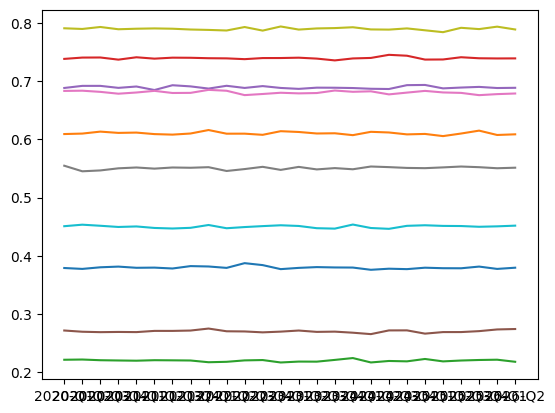

In [116]:
for x,industry in enumerate(industries):
    industry_data=data[data[cols[8]]==industry].groupby(quarter_lab).agg(ai_risk=(cols[9],'mean')).reset_index()
    plt.plot(quarter_lab,"ai_risk",data=industry_data,label=industry)

<function matplotlib.pyplot.show(close=None, block=None)>

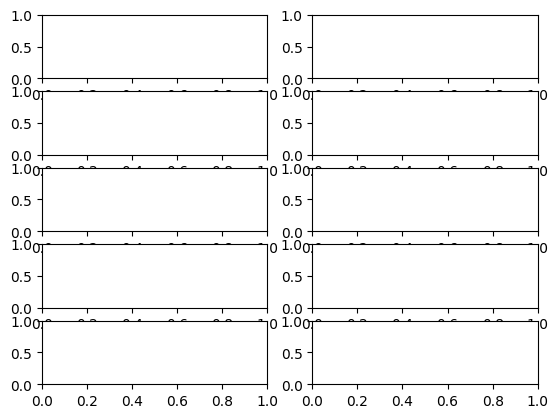

In [92]:
all_data=[]
for x,industry in enumerate(industries):
    industry_data=data[data[cols[8]]==industry].groupby(quarter_lab).agg(ai_risk=(cols[9],'mean')).reset_index()
    all_data.append([industry,industry_data])

In [96]:
all_data[0][1][quarter_lab]

0     2020-Q1
1     2020-Q2
2     2020-Q3
3     2020-Q4
4     2021-Q1
5     2021-Q2
6     2021-Q3
7     2021-Q4
8     2022-Q1
9     2022-Q2
10    2022-Q3
11    2022-Q4
12    2023-Q1
13    2023-Q2
14    2023-Q3
15    2023-Q4
16    2024-Q1
17    2024-Q2
18    2024-Q3
19    2024-Q4
20    2025-Q1
21    2025-Q2
22    2025-Q3
23    2025-Q4
24    2026-Q1
25    2026-Q2
Name: quarter_label, dtype: category
Categories (26, str): ['2020-Q1' < '2020-Q2' < '2020-Q3' < '2020-Q4' ... '2025-Q3' < '2025-Q4' < '2026-Q1' < '2026-Q2']

In [102]:
len(all_data)

10

Text(0.5, 1.0, 'AI automation risk for Technology & Software')

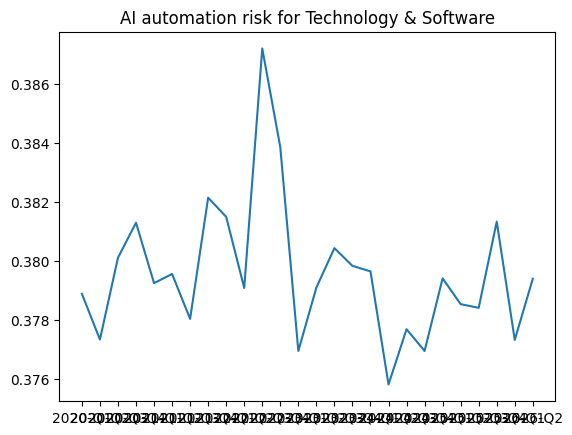

In [117]:
all_data[0]
plt.plot(all_data[0][1][quarter_lab],all_data[0][1]['ai_risk'])
plt.title(f"AI automation risk for {all_data[0][0]}")

In [121]:
all_data

[['Technology & Software',
     quarter_label   ai_risk
  0        2020-Q1  0.378887
  1        2020-Q2  0.377337
  2        2020-Q3  0.380112
  3        2020-Q4  0.381300
  4        2021-Q1  0.379250
  5        2021-Q2  0.379562
  6        2021-Q3  0.378037
  7        2021-Q4  0.382150
  8        2022-Q1  0.381500
  9        2022-Q2  0.379088
  10       2022-Q3  0.387213
  11       2022-Q4  0.383862
  12       2023-Q1  0.376950
  13       2023-Q2  0.379100
  14       2023-Q3  0.380437
  15       2023-Q4  0.379837
  16       2024-Q1  0.379650
  17       2024-Q2  0.375812
  18       2024-Q3  0.377688
  19       2024-Q4  0.376950
  20       2025-Q1  0.379413
  21       2025-Q2  0.378538
  22       2025-Q3  0.378412
  23       2025-Q4  0.381337
  24       2026-Q1  0.377325
  25       2026-Q2  0.379400],
 ['Finance & Banking',
     quarter_label   ai_risk
  0        2020-Q1  0.609000
  1        2020-Q2  0.609812
  2        2020-Q3  0.613175
  3        2020-Q4  0.610975
  4        2021-Q1  

In [125]:
for x in all_data:
    print(x[1])

   quarter_label   ai_risk
0        2020-Q1  0.378887
1        2020-Q2  0.377337
2        2020-Q3  0.380112
3        2020-Q4  0.381300
4        2021-Q1  0.379250
5        2021-Q2  0.379562
6        2021-Q3  0.378037
7        2021-Q4  0.382150
8        2022-Q1  0.381500
9        2022-Q2  0.379088
10       2022-Q3  0.387213
11       2022-Q4  0.383862
12       2023-Q1  0.376950
13       2023-Q2  0.379100
14       2023-Q3  0.380437
15       2023-Q4  0.379837
16       2024-Q1  0.379650
17       2024-Q2  0.375812
18       2024-Q3  0.377688
19       2024-Q4  0.376950
20       2025-Q1  0.379413
21       2025-Q2  0.378538
22       2025-Q3  0.378412
23       2025-Q4  0.381337
24       2026-Q1  0.377325
25       2026-Q2  0.379400
   quarter_label   ai_risk
0        2020-Q1  0.609000
1        2020-Q2  0.609812
2        2020-Q3  0.613175
3        2020-Q4  0.610975
4        2021-Q1  0.611513
5        2021-Q2  0.608912
6        2021-Q3  0.608012
7        2021-Q4  0.609925
8        2022-Q1  0.615900
9

In [25]:
cols[9]

'sector_automation_risk_score'

In [27]:
data.groupby(cols[8])[cols[9]].mean()

industry_sector
Administrative & Clerical     0.789742
Education & Research          0.270071
Energy & Utilities            0.449988
Finance & Banking             0.610245
Healthcare & Life Sciences    0.219736
Manufacturing & Industry      0.739386
Media & Communications        0.550444
Retail & E-Commerce           0.689231
Technology & Software         0.379583
Transportation & Logistics    0.680379
Name: sector_automation_risk_score, dtype: float64

0        0.382
1        0.608
2        0.198
3        0.720
4        0.676
         ...  
20795    0.308
20796    0.675
20797    0.516
20798    0.801
20799    0.440
Name: sector_automation_risk_score, Length: 20800, dtype: float64

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [103]:
for industry in data[cols[8]].unique():
    df=data[data[cols[8]]==industry]
    print(df[cols[9]].mean())

0.37958269230769226
0.6102447115384615
0.21973557692307694
0.7393860576923076
0.6892312500000001
0.2700711538461539
0.680379326923077
0.5504442307692308
0.7897423076923078
0.44998798076923074


In [104]:
# AI Automation risk overtime for all industries in facet grid for comparison

SyntaxError: invalid syntax (1983078972.py, line 1)